<a href="https://colab.research.google.com/github/chantal-e/Startup-Funding-and-Outcome-Analysis/blob/main/startup_funding_and_outcome_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up notebook

We import pandas, and set up the csv file so it is easy to use throughout the analysis.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/chantal-e/Startup-Funding-and-Outcome-Analysis/main/data/startup_success_dataset.csv"
df = pd.read_csv(url)
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


# Exploratory Data Analysis (EDA)

First, we check the structure of our dataset and look for missing values. This helps us understand the data types, number of entries, and whether we need to clean the data.

In [2]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


,0
funding_rounds,0
founder_experience_years,0
team_size,0
market_size_billion,0
product_traction_users,0
burn_rate_million,0
revenue_million,0
investor_type,0
sector,0
founder_background,0


**Observation:**  
- The dataset has 100,000 rows and 11 columns.  
- All columns have complete data (no missing values).  
- Numeric columns: funding, experience, team size, market size, users, burn rate, and revenue.  
- Categorical columns: investor type, sector, founder background, and outcome.  

This means we can start analysis directly without cleaning missing values.

## Outcome Overview

We are going to view how many startups fall into IPO, Aquisition or Failure using a bar chart.

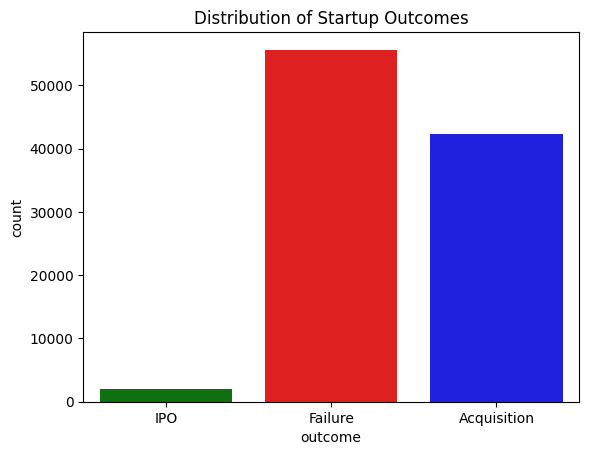

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

distribution_outcome = {'IPO':'g', 'Failure':'r', 'Acquisition':'b'}
sns.countplot(x='outcome',
              hue = df['outcome'],
              palette= distribution_outcome,
              data=df)
plt.title("Distribution of Startup Outcomes")
plt.show()

## Overall Startup Outcomes

We calculate the percentage of startups in each outcome category (IPO, Acquisition, Failure) to understand the general success/failure distribution in the dataset.

In [4]:
outcome_percentage = df['outcome'].value_counts(normalize=True) * 100
outcome_percentage = outcome_percentage.round(2)
print(outcome_percentage)

outcome
Failure        55.61
Acquisition    42.34
IPO             2.05
Name: proportion, dtype: float64


**Observation:**  
- Majority of startups failed (55.61%), while 42.34% were acquired and 2.05% reached IPO.  

This gives a baseline understanding of startup success rates before diving into sector, funding, or founder analysis.

## Funding Rounds vs Outcomes

After seeing the outcome percentages, we will now see if the amount of funding in each start up correlates to their success.

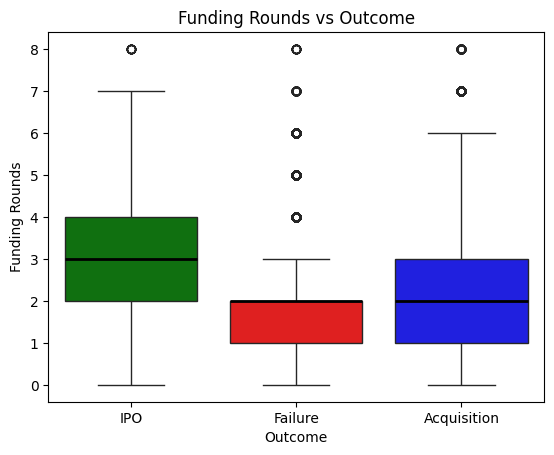

In [10]:
funding_vs_outcome = {'IPO':'g', 'Failure':'r', 'Acquisition':'b'}
sns.boxplot(data=df, x = 'outcome',
            y = 'funding_rounds',
            hue = df['outcome'],
            palette = funding_vs_outcome,
            medianprops = dict(color = 'black', linewidth = 2))
plt.title('Funding Rounds vs Outcome')
plt.xlabel('Outcome')
plt.ylabel('Funding Rounds')
plt.show()

 **Observation:**

*Median*
* IPO startups have a median of 3 funding rounds, while both Failure and Acquisitio have a median of 2 funding rounds. This suggests that startups that reach IPO typically go through more funding rounds before becoming successful.

*Box height (IQR)*
* IPO and Aquisition startups show a similar spread in funding rounds (IQR of 2), suggesting comparable variabilty. However, IPO startups have higher funding rounds overall, with their IQR sitting one round higher than Aquisition startups.

*Whiskers*
* All three groups have lower whiskers reaching 0, meaning some startups in every outcome category had zero funding rounds, this includes startups that still managed an IPO or acquisition. The upper whiskers tell us IPO and Acquisition startups reach 7 and 6 rounds respectively, whereas Failure's upper whisker only extends to 3. This asymmetry suggests that sustained investor backing across multiple rounds is more commonly associated with positive outcomes, and that raising more than 3 rounds while still failing is already an outlier behaviour.

*Outliers*
* Failure has noticeably more outliers (5, 6, 7, 8 funding rounds) than IPO and Aquisition. This shows that some startups raised many rounds but still failed, whhich might suggest that more funding doesn't necessarily mean success.

*Key Takeaway*
* IPO startups tend to have more funding rounds on average (median of 3 and 2 for Failure and Acquisition), but the groups overlap significantly in their IQR ranges. This suggests funding rounds alone is not a strong predictor of outcome, and that other factors, such as investor type or founder background, may play a more influential role in determining startup success."


## Investor Type vs Outcome

After seeing Funding vs Outcome, we will now see if Investor Type has influence on the success of a startup.

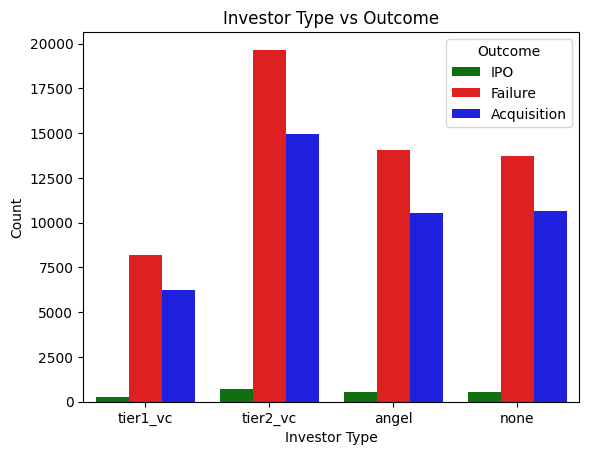

In [6]:
investor_order = ['tier1_vc', 'tier2_vc', 'angel', 'none']
sns.countplot(x='investor_type',
              hue='outcome',
              palette= funding_vs_outcome,
              order = investor_order,
              data=df)
plt.title("Investor Type vs Outcome")
plt.xlabel("Investor Type")
plt.ylabel("Count")
plt.legend(title="Outcome")
plt.show()

**Observation**

* The grouped bar chart shows that tier 2 VC-backed startups appear to have significantly more failures, acquisitions and IPOs in absolute terms. However, this is misleading as the groups vary considerably in size, tier 2 has a far greater number of startups in the dataset than tier 1.

To account for the difference in group sizes, we shall normalise the data to show proportions within each investor type. This allows for a fairer comparison of outcomes across groups.

In [7]:
ct = pd.crosstab(df['investor_type'], df['outcome'], normalize='index') * 100
ct = ct.reindex(['tier1_vc', 'tier2_vc', 'angel', 'none'])

print(ct)

outcome        Acquisition    Failure       IPO
investor_type                                  
tier1_vc         42.399455  55.705521  1.895024
tier2_vc         42.333060  55.657146  2.009794
angel            41.910331  55.889724  2.199944
none             42.729028  55.203893  2.067080


**Observation**

* All four investor types show remarkably similar outcome proportions, with failure rates consistently around 55%, acquisition rates around 42%, and IPO rates around 2% regardless of investor type.

* The normalised chart reveals that investor type has virtually no impact on startup outcome in this dataset, challenging the assumption that prestigious backing guarantees success. This suggests that other factors may be stronger predictors of outcome.

##Sector Type vs Outcome

Now we're going to see if the type of sector that new startups are in have an influence on the success of the startup.

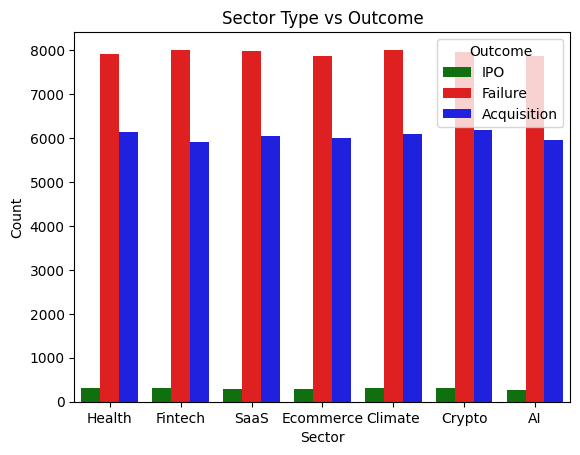

In [8]:
sns.countplot(x='sector',
              hue='outcome',
              palette= funding_vs_outcome,
              data=df)

plt.title('Sector Type vs Outcome')
plt.xlabel("Sector")
plt.ylabel("Count")
plt.legend(title="Outcome")
plt.show()

**Observation**

*   Upon observation, we can see that the sectors all have a similiar success rate. To see if we are correct in our judgement, we need to normalise the data and see the percentage of the outcomes for each sector.



In [9]:
ct2 = pd.crosstab(df['sector'], df['outcome'], normalize='index') * 100
print(ct2)

outcome    Acquisition    Failure       IPO
sector                                     
AI           42.290749  55.861873  1.847378
Climate      42.311962  55.537052  2.150985
Crypto       42.798838  55.098229  2.102933
Ecommerce    42.401753  55.576760  2.021487
Fintech      41.561181  56.322082  2.116737
Health       42.731768  55.157763  2.110469
SaaS         42.238192  55.731529  2.030280


**Observation**
* Across all sector types we see that there is a similar success rate, with around 42% in Aquisition, around 55%-56% in Failure, and IPO rates around 2%.

* With AI having the lowest IPO rate and the highest failure rate than other sectors, the differences are extremely small and not meaningful enough to say that AI companies do not perform well.

* Overall, the data indicates that sector alone does not determine the success of startup companies.